# AFM simulation and CNN


**This notebook provides a complete example on how to create a simulated AFM dataset and how to train a regression model for post-processing.**

The first section simulates a dataset while the second section builds and trains a model. Finally, the user can test the model on their experimental data. The notebook provides two final **Output**; **1:** A simulated AFM dataset, **2:** A trained model ready to process experimental data.

## 1. Optional installations

Uncomment the lines you need in a fresh environment.


In [76]:
#!pip3 install deeplay plotly ipywidgets ipympl


## 2. Imports and configuration

Here we import necessary libraries and scripts.

In [ ]:
import os

from __future__ import annotations

from dataclasses import dataclass
from typing import List

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

torch.set_num_threads(1)

SEED = 69
np.random.seed(SEED)
torch.manual_seed(SEED)

Array = np.ndarray


@dataclass
class SimulationConfig:
    nx = 16
    ny = 16
    pixel_size_m = 2e-6
    z_length_m = 3e-6
    sampling_frequency_hz = 100
    n_points_per_phase = 512
    approach_rate_um_s = 2.0
    retract_rate_um_s = 2.0
    tip_shape = "Sphere"
    include_thermal_noise = True
    noise_type = "experimental"
    experimental_noise_path = "../data/thermal-noise-data_vDeflection_2025.11.28-16.42.57.tnd"
    setpoint_force_n = 1.0e-9
    retract_distance_m = 3.0e-6


@dataclass
class DatasetConfig:
    n_train_samples = 5
    n_val_samples = 3
    n_test_samples = 1
    topography_types = ("gaussian_features", "hemisphere")
    substrate_stiffness_range_pa = (2e3, 3e3)
    feature_stiffness_range_pa = (0.5e3, 2e3)
    height_range_m = (1e-6, 1.5e-6)
    # Expanded to include early-contact regime seen in experimental curves.
    contact_point_range_m = (0.01e-6, 1.65e-6)


@dataclass
class ModelConfig:
    batch_size = 256
    learning_rate = 2e-3
    max_epochs =20
    predict_contact_point = True
    cp_loss_weight = 0.5
    num_workers = 0
    accelerator = "cpu"
    devices = 1
    default_sample_to_display = 0


simulation_config = SimulationConfig()
dataset_config = DatasetConfig()
model_config = ModelConfig()

print(simulation_config)
print(dataset_config)
print(model_config)


SimulationConfig()
DatasetConfig()
ModelConfig()


## 3. Cantilever model with PSD


The `AFMCantilever` class represents the physical cantilever. Required inputs are: tip geometry, tip size, spring constant, resonance frequency, quality factor, and temperature — all available on the cantilever box or thermal calibration file.

The class handles two responsibilities: computing the contact area for a given indentation, and generating thermal noise. Three noise options are provided:

1. **Equipartition theorem**: The mean square displacement of the cantilever under thermal fluctuations is equal to `k_B T / k` under the equipartitoin theorem. In order to use this option the spring constant of the cantilever and the temperature we operate in must be known. If the user has only acces to these parameters they can select 'rms' for noise type. 
2. **Theoretical PSD**: The cantilever behaves as a damped harmonic oscillator for which we can compute the power spectral density (PSD). Depending on our sampling frequency we compute a time domain noise from the theoretical PSD. In order to use this option alongside the spring constant and the temperature the user must also know the resonant frequency and the quality factor of their cantilever. To select this option input 'Theoretical' in the noise type.
3. **Experimental PSD**: In the beginning of an AFM experiment the software measures the PSD of the cantilever in order to do thermal calibration. This file also contains the necessary information on the cantilever. In this option the time domain noise is generated from the experimental PSD. To select this option input 'Experimental' in the noise type and provide the path that leads to the '.tnd' calibration file.

In [ ]:
class AFMCantilever:
    """AFM cantilever model with thermal-noise PSD support. This class represent 
    the cantilever and stores parameters relevant to its thermal noise characteristics, 
    allowing for both theoretical and experimental PSDs to be used in simulations.

    Parameters
    ----------
    k : float
        Spring constant in N/m.
    f0 : float
        Resonance frequency in Hz.
    Q : float
        Quality factor.
    T : float
        Temperature in kelvin.

    """

    def __init__(
        self, 
        k: float =10, 
        f0: float =7e3, 
        Q: float =10.0, 
        T: float =300.0
        ) -> None:
        self.k = k
        self.f0 = f0
        self.Q = Q
        self.T = T
        self.kB = 1.380649e-23
        self.m_eff = k / (2.0 * np.pi * f0) ** 2
        self.gamma = 2.0 * np.pi * f0 * self.m_eff / Q
        self._experimental_psd_cache = {}
        self._grid_psd_cache = {}

    def thermal_noise_rms(self):
        """Return the RMS thermal deflection in meters."""
        return np.sqrt(self.kB * self.T / self.k)

    def thermal_noise_psd_theoretical(
        self, 
        frequency_hz: np.ndarray
        ) -> np.ndarray:
        """Return the one-sided theoretical displacement PSD.

        Parameters
        ----------
        frequency_hz : ndarray

        Returns
        -------
        ndarray
            PSD in m^2/Hz.
        """
        omega  = 2.0 * np.pi * frequency_hz
        omega0 = 2.0 * np.pi * self.f0
        denom  = (omega0**2 - omega**2)**2 + (omega * omega0 / self.Q)**2
        return (4.0 * self.kB * self.T * self.gamma) / (self.k**2 * denom)

    def thermal_noise_psd_experimental(
        self, 
        path: str
        ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Load and cache an experimental displacement PSD.

        Parameters
        ----------
        path : str

        Returns
        -------
        tuple of ndarray
            (frequency_hz, spectral_density_x, spectral_density_x_fit)
        """
        cache_key = str(path)
        if cache_key not in self._experimental_psd_cache:
            data = np.loadtxt(path, skiprows=24)
            frequency_hz       = data[:, 0]
            spectral_density_v = data[:, 1]
            spectral_density_v_fit = data[:, 3]
            with open(path, "r") as f:
                lines = f.readlines()
            for line in lines:
                if "sensitivity" in line:
                    volts_to_displacement_nm = float(line.split(":")[1].split()[0])
                if "parameter.f" in line:
                    self.f0 = float(line.split(":")[1].split()[0]) * 1e3
                if "parameter.Q" in line:
                    self.Q = float(line.split(":")[1].split()[0])
            scale = volts_to_displacement_nm * 1e-9
            self._experimental_psd_cache[cache_key] = (
                frequency_hz,
                spectral_density_v     * scale**2,
                spectral_density_v_fit * scale**2,
            )
        return self._experimental_psd_cache[cache_key]

    def get_noise_psd(
        self, 
        n_points: int, 
        sampling_frequency_hz: float,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path
        ) -> tuple[np.ndarray, np.ndarray]:
        """Return the simulation-grid PSD, reusing cached results when possible.

        Parameters
        ----------
        n_points : int
        sampling_frequency_hz : float
        noise_type : str
        experimental_path : str or None

        Returns
        -------
        tuple of ndarray
            (frequency_hz, spectral_density_x)
        """
        cache_key = (noise_type.lower(), int(n_points), float(sampling_frequency_hz),
                     None if experimental_path is None else str(experimental_path))
        if cache_key in self._grid_psd_cache:
            return self._grid_psd_cache[cache_key]

        frequency_hz = np.fft.rfftfreq(n_points, d=1.0 / sampling_frequency_hz)
        if noise_type.lower() == "theoretical":
            spectral_density_x = self.thermal_noise_psd_theoretical(frequency_hz)
        elif noise_type.lower() == "experimental":
            if experimental_path is None:
                raise ValueError("`experimental_path` must be provided for experimental PSD.")
            frequency_hz, spectral_density_x, _ = (
                self.thermal_noise_psd_experimental(experimental_path)
            )
        else:
            raise ValueError(f"Unknown noise type: {noise_type}")

        self._grid_psd_cache[cache_key] = (frequency_hz, spectral_density_x)
        return self._grid_psd_cache[cache_key]

    def sample_thermal_noise(
        self, 
        n_points: int, 
        sampling_frequency_hz: float,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
        rng=None
        ) -> np.ndarray:
        """Draw one thermal-noise trace using random phases from the PSD.

        Parameters
        ----------
        n_points : int
        sampling_frequency_hz : float
        noise_type : str
        experimental_path : str or None
        rng : numpy.random.Generator or None

        Returns
        -------
        ndarray
            Noise trace in meters, shape (n_points,).
        """
        rng = np.random.default_rng() if rng is None else rng
        frequency_hz, spectral_density_x = self.get_noise_psd(
            n_points, sampling_frequency_hz, noise_type, experimental_path
        )
        df        = sampling_frequency_hz / n_points

        amplitude = n_points * np.sqrt(np.maximum(spectral_density_x * df/2, 0.0))
        coefficients = np.zeros(amplitude.shape[0], dtype=np.complex128)

        if amplitude.shape[0] > 2:
            phase = rng.uniform(0.0, 2.0 * np.pi, size=amplitude.shape[0] - 2)
            coefficients[1:-1] = amplitude[1:-1] * np.exp(1j * phase)
        coefficients[0] = 0.0
        if n_points % 2 == 0 and amplitude.shape[0] > 1:
            coefficients[-1] = amplitude[-1] * np.sign(rng.standard_normal())
            
        noise_m = np.fft.irfft(coefficients, n=n_points).real
        rms      = self.thermal_noise_rms()
        std      = np.std(noise_m)
        # Guard against zero std (happens when n_points is very small and no
        # random phases were drawn, leaving coefficients all zero).
        if std > 0:
            noise_m = noise_m / std * rms
        else:
            noise_m = rng.normal(scale=rms, size=n_points)
        return noise_m


**Thermal noise from file**

Uncomment and run this cell if you wish to load an experimental thermal calibration file. When running locally, store the file in the folder with the script and make sure that the path is accessible.

In [91]:
# from google.colab import files
# import os

# print("Upload your experimental PSD text file (e.g., .txt or .csv):")
# uploaded = files.upload()
# for filename in uploaded.keys():
#      print(f'Uploaded "{filename}" ({len(uploaded[filename])} bytes)')
#      simulation_config.experimental_noise_path = filename
#      simulation_config.noise_type = "Experimental"


## 4. Contact mechanics


The `HertzContact` class transforms indentation depth into a force response. The Hertz model is provided as an example suited to biological applications. You can replace it with any contact model appropriate for your experiment.

In [ ]:
class HertzContact:
    """Hertz contact model for spherical and pyramidal tips.

    Args:
        R: Tip radius in meters.
        nu: Poisson ratio of the sample.
        alpha: Pyramid face angle in degrees.
    """

    def __init__(
        self, 
        R: float = 10e-9, 
        nu: float = 0.5, 
        alpha: float = 18.0
        ) -> None:
        self.R = R
        self.nu = nu
        self.alpha = alpha

    @property
    def alpha_rad(
        self
        ) -> float:
        """Return the pyramid face angle in radians."""
        return np.deg2rad(self.alpha)

    def hertz_sphere(
        self, 
        indentation_m: float, 
        stiffness_pa: float
        ) -> float:
        """Return the Hertz force for a spherical tip."""
        return (
            (4.0 / 3.0)
            * stiffness_pa
            * np.sqrt(self.R)
            * indentation_m**1.5
            / (1.0 - self.nu**2)
        )

    def hertz_cone(
        self, 
        indentation_m: float, 
        stiffness_pa: float
        ) -> float:
        """Return the Hertz-like force for a conical approximation."""
        return (
            stiffness_pa
            * np.tan(self.alpha_rad)
            * indentation_m**2
            / (np.sqrt(2.0) * (1.0 - self.nu**2))
        )

    def force(
        self, 
        cantilever_shape: str, 
        indentation_m: float, 
        stiffness_pa: float
        ) -> float:
        """Return the contact force for the given indentation.

        Args:
            cantilever_shape: Tip geometry, either ``'Sphere'`` or ``'Pyramid'``.
            indentation_m: Indentation depth in meters.
            stiffness_pa: Young's modulus in pascal.

        Returns:
            Contact force in newtons.
        """
        indentation_safe_m = np.maximum(np.asarray(indentation_m, dtype=np.float64), 0.0)
        if cantilever_shape == "Sphere":
            return self.hertz_sphere(indentation_safe_m, stiffness_pa)
        if cantilever_shape == "Pyramid":
            return self.hertz_cone(indentation_safe_m, stiffness_pa)
        raise ValueError(f"Unsupported cantilever shape: {cantilever_shape}")


## 5. Synthetic sample-map generator


The `SampleGenerator` class builds a synthetic sample. You provide topography type and mechanical property ranges; the class returns a 2D topography map, a stiffness map, and a **contact point map**.

### Contact point convention

The contact point is defined as the **absolute z-position along the displacement axis** at which the tip first touches the sample surface. A large contact-point value means the tip is still far from the surface when first contact occurs (i.e., the approach has barely started). A small value means the tip nearly traverses the full scan range before touching.




In [ ]:
class SampleGenerator:
    """Generate topography, stiffness, and contact-point maps."""

    def __init__(
        self,
        substrate_stiffness_range_pa: tuple = (5e3, 10e3),
        feature_stiffness_range_pa: tuple = (2e3, 5e3),
        height_range_m: tuple = (1e-6, 4e-6),
        contact_point_range_m: tuple = (5.0e-6, 9.75e-6),
        ) -> None:
        self.substrate_stiffness_range_pa = substrate_stiffness_range_pa
        self.feature_stiffness_range_pa = feature_stiffness_range_pa
        self.height_range_m = height_range_m
        self.contact_point_range_m = contact_point_range_m

    def create_topography(
        self, 
        size: tuple = (128, 128), 
        pixel_size_m: float = 1e-6,
        topography_type: str = "gaussian_features", 
        rng=None
        ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Create one synthetic sample map.

        Args:
            size: Map dimensions as ``(ny, nx)`` in pixels.
            pixel_size_m: Physical size of one pixel in meters.
            topography_type: ``'gaussian_features'`` or ``'hemisphere'``.
            rng: Optional numpy random generator.

        Returns:
            Tuple of ``(topography_m, stiffness_map_pa, contact_point_map_m)``.
        """
        rng = np.random.default_rng() if rng is None else rng
        ny, nx = size
        topography_m = np.ones((ny, nx), dtype=np.float64) * 1e-8
        stiffness_map_pa = rng.uniform(
            self.substrate_stiffness_range_pa[0],
            self.substrate_stiffness_range_pa[1],
            size=(ny, nx),
        )

        if topography_type == "gaussian_features":
            n_features = int(rng.integers(4, 10))
            y, x = np.ogrid[0:ny, 0:nx]
            for _ in range(n_features):
                cx = int(rng.integers(0, nx))
                cy = int(rng.integers(0, ny))
                amplitude = float(rng.uniform(*self.height_range_m))
                sigma_px = float(rng.uniform(3.0, 10.0))
                gaussian = amplitude * np.exp(
                    -((x - cx) ** 2 + (y - cy) ** 2) / (2.0 * sigma_px**2)
                )
                topography_m += gaussian
        elif topography_type == "hemisphere":
            radius_px = min(nx, ny) // 4
            cx, cy = nx // 2, ny // 2
            y, x = np.ogrid[:ny, :nx]
            r2 = (x - cx) ** 2 + (y - cy) ** 2
            mask = r2 <= radius_px**2
            topography_m[mask] = self.height_range_m[1] * np.sqrt(
                1.0 - r2[mask] / radius_px**2
            )
        else:
            raise ValueError(f"Unsupported topography type: {topography_type}")

        feature_mask = topography_m > np.percentile(topography_m, 70.0)
        stiffness_map_pa[feature_mask] = rng.uniform(
            self.feature_stiffness_range_pa[0],
            self.feature_stiffness_range_pa[1],
            size=int(feature_mask.sum()),
        )

        if float(topography_m.max()) > float(topography_m.min()):
            normalized_topography = (topography_m - topography_m.min()) / (
                topography_m.max() - topography_m.min()
            )
        else:
            normalized_topography = np.zeros_like(topography_m)

        cp_min, cp_max = self.contact_point_range_m
        contact_point_map_m = np.interp(
            normalized_topography,
            (0.0, 1.0),
            (cp_max, cp_min),
        )
        contact_point_map_m = np.clip(contact_point_map_m, cp_min, cp_max)

        return topography_m, stiffness_map_pa, contact_point_map_m


## 6. AFM simulator


The `AFMSimulator` combines all previous classes into a vectorised map simulator. It returns 2D maps of force-distance curves, each with additive thermal noise.

In [ ]:
class AFMSimulator:
    """AFM curve simulator with setpoint-triggered retract.

    The approach is stopped at the exact z-position where the Hertz force
    equals ``setpoint_force_n`` or exceeds it..

    Parameters
    ----------
    cantilever : AFMCantilever
    contact_model : HertzContact
    sample_generator : SampleGenerator
    config : SimulationConfig
    """

    def __init__(
        self, 
        cantilever, 
        contact_model, 
        sample_generator, 
        config
        ) -> None:
        self.cantilever      = cantilever
        self.contact_model   = contact_model
        self.sample_generator = sample_generator
        self.config          = config
        self.n_points_approach = self._compute_n_points_approach()
        self.approach_axis_m   = self._build_approach_axis()

    def _compute_n_points_approach(
        self
        ) -> int:
        total_time_s = self.config.z_length_m / (self.config.approach_rate_um_s * 1e-6)
        return max(32, int(np.ceil(total_time_s * self.config.sampling_frequency_hz)))

    def _build_approach_axis(
        self
        ) -> np.ndarray:
        return np.linspace(0.0, self.config.z_length_m, self.n_points_approach,
                           endpoint=True, dtype=np.float64)

    def _retract_axis(
        self, 
        z_start_m: float
        ) -> np.ndarray:
        """Return the retract displacement axis starting from ``z_start_m``."""
        z_stop_m = max(0.0, z_start_m - self.config.retract_distance_m)
        if z_stop_m >= z_start_m:
            return np.zeros(0, dtype=np.float64)
        n = max(1, int(np.ceil(
            (z_start_m - z_stop_m) / (self.config.retract_rate_um_s * 1e-6)
            * self.config.sampling_frequency_hz
        )))
        return np.linspace(z_start_m, z_stop_m, n + 1, endpoint=True)[1:].astype(np.float64)

    def simulate_force_map(
        self, 
        stiffness_map_pa: np.ndarray, 
        contact_point_map_m: np.ndarray,
        include_thermal_noise: bool = True,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
        rng: np.random.Generator = None
        ) -> dict:
        """Simulate a map of force curves with exact setpoint termination.

        Parameters
        ----------
        stiffness_map_pa : np.ndarray, shape (ny, nx)
        contact_point_map_m : np.ndarray, shape (ny, nx)
        include_thermal_noise : bool, optional
        noise_type : str, optional
        experimental_path : str or None, optional
        rng : numpy.random.Generator or None, optional

        Returns
        -------
        dict
            Keys: ``displacement_curves_m``, ``force_curves_n``,
            ``measured_force_curves_n``, ``curve_lengths``,
            ``retract_start_indices``, ``contact_indices``.
        """
        rng = np.random.default_rng() if rng is None else rng
        ny, nx = stiffness_map_pa.shape

        # Vectorised approach force over the full grid.
        approach_indent = np.maximum(
            self.approach_axis_m[None, None, :] - contact_point_map_m[..., None], 0.0
        )
        approach_force = self.contact_model.force(
            cantilever_shape=self.config.tip_shape,
            indentation_m=approach_indent,
            stiffness_pa=stiffness_map_pa[..., None],
        )  # (ny, nx, n_points_approach)

        # First grid index where force >= setpoint.
        exceeded       = approach_force >= self.config.setpoint_force_n  
        first_exceed   = np.argmax(exceeded, axis=-1)                    # (ny, nx)
        never_reached  = ~np.any(exceeded, axis=-1)
        first_exceed[never_reached] = self.n_points_approach - 1

        # Contact index (first sample at or past the contact point).
        contact_indices = np.clip(
            np.searchsorted(self.approach_axis_m, contact_point_map_m.ravel(), side="left"),
            0, self.n_points_approach - 1,
        ).reshape(contact_point_map_m.shape)

        # Per-pixel variable-length curves.
        displacement_curves_m   = np.empty((ny, nx), dtype=object)
        force_curves_n          = np.empty((ny, nx), dtype=object)
        measured_force_curves_n = np.empty((ny, nx), dtype=object)
        curve_lengths           = np.zeros((ny, nx), dtype=np.int32)
        retract_start_indices   = np.zeros((ny, nx), dtype=np.int32)

        for r in range(ny):
            for c in range(nx):
                cp    = float(contact_point_map_m[r, c])
                E     = float(stiffness_map_pa[r, c])
                ei    = int(first_exceed[r, c])
                never = bool(never_reached[r, c])

                # ── approach ─────────────────────────────────────────────────
                if never or ei == 0:
                    app_z = self.approach_axis_m.copy()
                    app_f = approach_force[r, c].copy()
                else:
                    app_z = self.approach_axis_m[:ei]
                    app_f = approach_force[r, c, :ei]
                

                # ── retract ───────────────────────────────────────────────────
                ret_z = self._retract_axis(float(app_z[-1]))

                ret_f = self.contact_model.force(
                    self.config.tip_shape,
                    np.maximum(ret_z - cp, 0.0),
                    E,
                )

                disp_z  = np.concatenate([app_z, ret_z])
                force_n = np.concatenate([app_f, ret_f])

                # ── thermal noise ─────────────────────────────────────────────
                noise_m = np.zeros_like(force_n)
                if include_thermal_noise:
                    noise_m = self.cantilever.sample_thermal_noise(
                        n_points=disp_z.size,
                        sampling_frequency_hz=self.config.sampling_frequency_hz,
                        noise_type=noise_type,
                        experimental_path=experimental_path,
                        rng=rng,
                    )

                displacement_curves_m[r, c]   = disp_z
                force_curves_n[r, c]          = force_n
                measured_force_curves_n[r, c] = force_n + noise_m * self.cantilever.k
                curve_lengths[r, c]           = disp_z.size
                retract_start_indices[r, c]   = app_z.size

        return {
            "displacement_curves_m":   displacement_curves_m,
            "force_curves_n":          force_curves_n,
            "measured_force_curves_n": measured_force_curves_n,
            "curve_lengths":           curve_lengths,
            "retract_start_indices":   retract_start_indices,
            "contact_indices":         contact_indices,
        }


## 7. Plotting utilities


Helper functions for visualising simulator outputs.

In [ ]:
def plot_maps(
    topography_m: ndarray, 
    stiffness_map_pa: ndarray, 
    contact_point_map_m: ndarray
    ) -> None:
    """Plot topography, stiffness, and contact-point maps side by side."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = axes[0].imshow(topography_m * 1e6, cmap="viridis", aspect="equal")
    axes[0].set_title("Topography [µm]")
    axes[0].set_xlabel("X [pixel]")
    axes[0].set_ylabel("Y [pixel]")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(stiffness_map_pa / 1e3, cmap="magma", aspect="equal")
    axes[1].set_title("Stiffness [kPa]")
    axes[1].set_xlabel("X [pixel]")
    axes[1].set_ylabel("Y [pixel]")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(contact_point_map_m * 1e6, cmap="cividis", aspect="equal")
    axes[2].set_title("Contact point [µm]")
    axes[2].set_xlabel("X [pixel]")
    axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    plt.tight_layout()
    plt.savefig('results/example_gaus.png')
    plt.show()


def plot_force_curve(
    displacement_curve_m: ndarray, 
    force_curve_n: ndarray, 
    retract_start_index: int = None,
    valid_length: int = None, 
    title: str = "Force curve"
   ) -> None:
    """Plot one force curve with approach and retract segments."""
    if valid_length is None:
        valid_length = int(len(displacement_curve_m))
    if retract_start_index is None:
        retract_start_index = valid_length // 2

    displacement_curve_m = np.asarray(displacement_curve_m[:valid_length], dtype=np.float64)
    force_curve_n = np.asarray(force_curve_n[:valid_length], dtype=np.float64)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        displacement_curve_m[:retract_start_index] * 1e6,
        force_curve_n[:retract_start_index] * 1e9,
        label="Approach",
    )
    ax.plot(
        displacement_curve_m[retract_start_index:] * 1e6,
        force_curve_n[retract_start_index:] * 1e9,
        label="Retract",
    )
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Force [nN]")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/fdc_ex.png')
    plt.show()


def plot_psd(
    frequency_hz: ndarray,
    spectral_density_m2_per_hz: ndarray,
    cantilever,
    sampling_frequency: float,
    title: str = "Displacement PSD",
   ) -> None:
    """Plot a square-root displacement PSD on log-log axes."""
    fig, ax = plt.subplots(figsize=(7, 4))
    in_band = frequency_hz <= (sampling_frequency / 2.0)
    ax.loglog(
        frequency_hz / 1e3,
        np.sqrt(spectral_density_m2_per_hz),
        linewidth=2.0,
        label="Full PSD",
    )
    ax.loglog(
        frequency_hz[in_band] / 1e3,
        np.sqrt(spectral_density_m2_per_hz[in_band]),
        linewidth=2.0,
        label="Within Nyquist",
    )
    ax.axvline(
        cantilever.f0 / 1e3,
        color="red",
        linestyle="--",
        label=f"f0 = {cantilever.f0 / 1e3:.1f} kHz",
    )
    ax.set_xlabel("Frequency [kHz]")
    ax.set_ylabel("Sqrt(PSD) [m / sqrt(Hz)]")
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/psd_ex.png')
    plt.show()


## 8. Instantiate the simulator and generate one example sample

Approach points = 150
Setpoint force = 1.00 nN
Retract distance = 3.00 µm


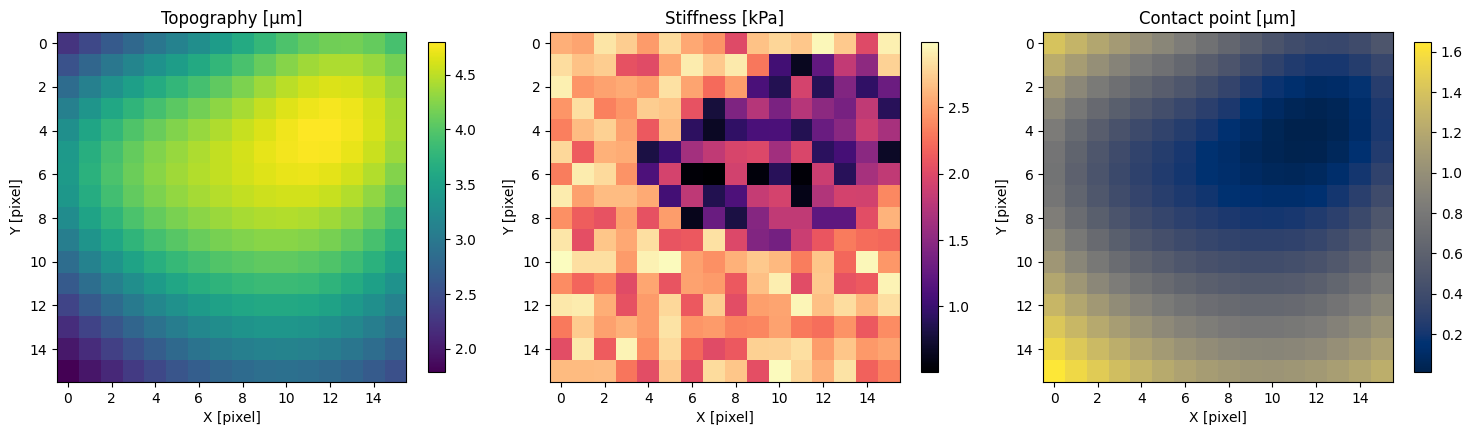

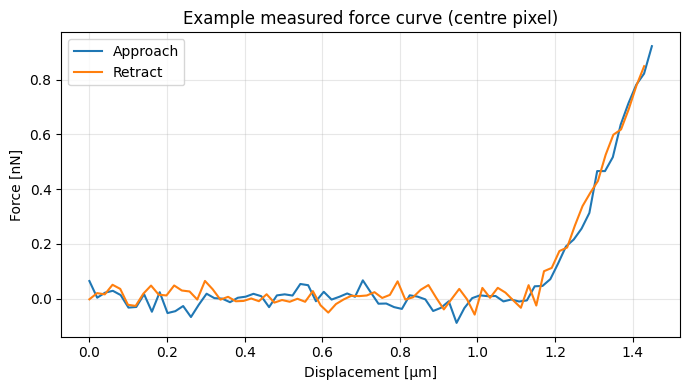

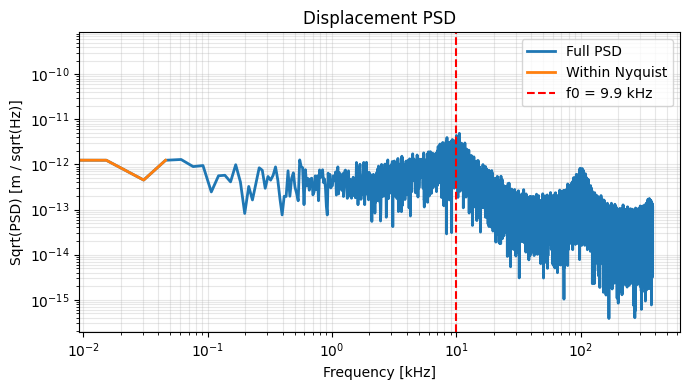

In [84]:
# We use the simulator to generate data and visualise it with the functions defined above.

rng = np.random.default_rng(SEED)

cantilever = AFMCantilever(k=0.2, f0=10e3, Q=100.0, T=300.0)
contact_model = HertzContact(R=1e-6, nu=0.5, alpha=18.0)
sample_generator = SampleGenerator(
    substrate_stiffness_range_pa=dataset_config.substrate_stiffness_range_pa,
    feature_stiffness_range_pa=dataset_config.feature_stiffness_range_pa,
    height_range_m=dataset_config.height_range_m,
    contact_point_range_m=dataset_config.contact_point_range_m,
)
simulator = AFMSimulator(
    cantilever=cantilever,
    contact_model=contact_model,
    sample_generator=sample_generator,
    config=simulation_config,
)

print(f"Approach points = {simulator.n_points_approach}")
print(f"Setpoint force = {simulation_config.setpoint_force_n * 1e9:.2f} nN")
print(f"Retract distance = {simulation_config.retract_distance_m * 1e6:.2f} µm")

example_topography_m, example_stiffness_pa, example_contact_point_m = (
    sample_generator.create_topography(
        size=(simulation_config.ny, simulation_config.nx),
        pixel_size_m=simulation_config.pixel_size_m,
        topography_type="gaussian_features",
        rng=rng,
    )
)

example_output = simulator.simulate_force_map(
    stiffness_map_pa=example_stiffness_pa,
    contact_point_map_m=example_contact_point_m,
    include_thermal_noise=simulation_config.include_thermal_noise,
    rng=rng,
)

plot_maps(example_topography_m, example_stiffness_pa, example_contact_point_m)

center_row = simulation_config.ny // 16
center_col = simulation_config.nx // 16
plot_force_curve(
    example_output["displacement_curves_m"][center_row, center_col],
    example_output["measured_force_curves_n"][center_row, center_col],
    retract_start_index=int(example_output["retract_start_indices"][center_row, center_col]),
    valid_length=int(example_output["curve_lengths"][center_row, center_col]),
    title="Example measured force curve (centre pixel)",
)

reference_points = max(simulator.n_points_approach * 2, 64)
frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
    n_points=reference_points,
    sampling_frequency_hz=simulation_config.sampling_frequency_hz*10,
    noise_type=simulation_config.noise_type,
    experimental_path=simulation_config.experimental_noise_path,
)
plot_psd(
    frequency_hz,
    spectral_density_m2_per_hz,
    cantilever,
    sampling_frequency=simulation_config.sampling_frequency_hz,
)


## 9. Convert force curves into ML inputs

In [ ]:
def compute_z_normalization(
    displacement_curves_um: ndarray, 
    valid_lengths: ndarray, 
    z_scale_um: float = None
    ) -> dict:
    """Compute single-value global z scaling from training data.

    Parameters
    ----------
    displacement_curves_um : ndarray, shape (n_samples, ny, nx, max_len)
    valid_lengths : ndarray, shape (n_samples, ny, nx)
    z_scale_um : float or None
        If provided, use this fixed value directly.

    Returns
    -------
    dict
        Keys: ``z_scale_um``.
    """
    if z_scale_um is not None:
        return {"z_scale_um": float(z_scale_um)}

    n_samples, ny, nx, _ = displacement_curves_um.shape
    z_values = []
    for s in range(n_samples):
        for r in range(ny):
            for c in range(nx):
                vl = int(valid_lengths[s, r, c])
                if vl > 0:
                    z_values.append(np.asarray(displacement_curves_um[s, r, c, :vl], dtype=np.float64))

    if not z_values:
        return {"z_scale_um": 1.0}

    all_valid_z = np.concatenate(z_values, axis=0)
    # Robust single-value scale; preserves absolute level (no per-curve centering).
    z_scale = float(np.percentile(np.abs(all_valid_z), 99.0) + 1e-6)
    return {"z_scale_um": z_scale}


def build_force_inputs(
    measured_force_curves_nN: ndarray, 
    displacement_curves_um: ndarray,
    valid_lengths: ndarray, 
    retract_start_indices: ndarray,
    z_normalization_stats: dict
    ) -> dict:
    """Build force, valid-mask, phase, and globally-scaled z channels.

    Each curve is kept at its full padded length. The valid mask is 1 inside
    the active curve and 0 in the idle-noise tail. The phase channel is -1
    during approach and +1 during retract. The z channel is scaled with one
    global value from training stats (divide-only).

    Parameters
    ----------
    measured_force_curves_nN : ndarray, shape (n_samples, ny, nx, max_len)
    displacement_curves_um : ndarray, shape (n_samples, ny, nx, max_len)
    valid_lengths : ndarray, shape (n_samples, ny, nx)
    retract_start_indices : ndarray, shape (n_samples, ny, nx)
    z_normalization_stats : dict
        Keys: ``z_scale_um``.

    Returns
    -------
    dict
        Keys: ``raw_force_nN``, ``valid_mask``, ``phase_channel``, ``z_scaled_channel``.
    """
    n_samples, ny, nx, _ = measured_force_curves_nN.shape
    valid_mask = np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    phase_channel = np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    z_scaled_channel = np.zeros_like(measured_force_curves_nN, dtype=np.float32)

    z_scale = float(z_normalization_stats["z_scale_um"])

    for s in range(n_samples):
        for r in range(ny):
            for c in range(nx):
                vl = int(valid_lengths[s, r, c])
                rs = int(retract_start_indices[s, r, c])
                if vl <= 0:
                    continue

                valid_mask[s, r, c, :vl] = 1.0
                phase_channel[s, r, c, :rs] = -1.0
                phase_channel[s, r, c, rs:vl] = 1.0

                z_valid = np.asarray(displacement_curves_um[s, r, c, :vl], dtype=np.float64)
                z_scaled_channel[s, r, c, :vl] = (z_valid / (z_scale + 1e-30)).astype(np.float32)

    return {
        "raw_force_nN": measured_force_curves_nN.astype(np.float32),
        "valid_mask": valid_mask,
        "phase_channel": phase_channel,
        "z_scaled_channel": z_scaled_channel,
    }


def compute_force_normalization(
    raw_force_nN: np.ndarray, 
    valid_mask: np.ndarray
    ) -> dict:
    """Compute global force scaling from valid training points only.

    Parameters
    ----------
    raw_force_nN : np.ndarray
    valid_mask : np.ndarray

    Returns
    -------
    dict
        Keys: ``force_scale_nN``.
    """
    valid_values = raw_force_nN[valid_mask > 0.5]
    # Robust single-value force scale; preserves absolute level (divide-only).
    force_scale_nN = float(np.percentile(np.abs(valid_values), 99.0) + 1e-6)
    return {"force_scale_nN": force_scale_nN}


def normalize_force_channel(
    raw_force_nN: np.ndarray, 
    valid_mask: np.ndarray, 
    normalization_stats: dict
    ) -> np.ndarray:
    """Scale force channel with one global value; zero out padded tail.

    Parameters
    ----------
    raw_force_nN : np.ndarray
    valid_mask : np.ndarray
    normalization_stats : dict

    Returns
    -------
    np.ndarray, float32
    """
    force_scale = float(normalization_stats["force_scale_nN"])
    normalized = raw_force_nN / (force_scale + 1e-30)
    return (normalized * valid_mask).astype(np.float32)


def flatten_sample_axes(
    input_tensor: np.ndarray, 
    stiffness_maps_kpa: np.ndarray, 
    contact_point_maps_nm: np.ndarray
    ) -> dict:
    """Flatten (n_samples, ny, nx, ...) arrays into a curve-wise dataset.

    Parameters
    ----------
    input_tensor : np.ndarray, shape (n_samples, ny, nx, n_channels, n_sequence)
    stiffness_maps_kpa : np.ndarray
    contact_point_maps_nm : np.ndarray

    Returns
    -------
    dict
        Keys: ``curve_inputs``, ``stiffness_targets_kpa``,
        ``contact_point_targets_nm``.
    """
    n_samples, ny, nx, n_channels, n_sequence = input_tensor.shape
    return {
        "curve_inputs": input_tensor.reshape(n_samples * ny * nx, n_channels, n_sequence),
        "stiffness_targets_kpa": stiffness_maps_kpa.reshape(-1),
        "contact_point_targets_nm": contact_point_maps_nm.reshape(-1),
    }


## 10. Generate train / validation / test sample sets

The split is done at the **sample-map level** to avoid train/test leakage between neighbouring pixels from the same synthetic sample.


In [ ]:
def generate_sample_collection(
    n_samples: int, 
    simulator: AFMSimulator, 
    sample_generator: SampleGenerator,
    dataset_config: DatasetConfig, 
    max_curve_length: int, 
    seed: int
    ) -> dict:
    """Generate, simulate, and pad a collection of AFM sample maps.

    Curves are padded to ``max_curve_length`` with idle thermal noise so
    that all curves in the dataset share the same array length.

    Parameters
    ----------
    n_samples : int
    simulator : AFMSimulator
    sample_generator : SampleGenerator
    dataset_config : DatasetConfig
    max_curve_length : int
        All curves are padded to this length.
    seed : int

    Returns
    -------
    dict
        Keys: ``topography_maps_nm``, ``stiffness_maps_kpa``,
        ``contact_point_maps_nm``, ``displacement_curves_um``,
        ``measured_force_curves_nN``, ``curve_lengths``,
        ``retract_start_indices``, ``contact_indices``.
    """
    rng = np.random.default_rng(seed)
    ny = simulator.config.ny
    nx = simulator.config.nx

    topography_maps_nm = np.zeros((n_samples, ny, nx), dtype=np.float32)
    stiffness_maps_kpa = np.zeros((n_samples, ny, nx), dtype=np.float32)
    contact_point_maps_nm = np.zeros((n_samples, ny, nx), dtype=np.float32)
    displacement_curves_um = np.zeros((n_samples, ny, nx, max_curve_length), dtype=np.float32)
    measured_force_curves_nN = np.zeros((n_samples, ny, nx, max_curve_length), dtype=np.float32)
    curve_lengths = np.zeros((n_samples, ny, nx), dtype=np.int32)
    retract_start_indices = np.zeros((n_samples, ny, nx), dtype=np.int32)
    contact_indices = np.zeros((n_samples, ny, nx), dtype=np.int32)

    for i in range(n_samples):
        topography_type = rng.choice(dataset_config.topography_types)
        topo_m, stiff_pa, cp_m = sample_generator.create_topography(
            size=(ny, nx),
            pixel_size_m=simulator.config.pixel_size_m,
            topography_type=topography_type,
            rng=rng,
        )
        out = simulator.simulate_force_map(
            stiffness_map_pa=stiff_pa,
            contact_point_map_m=cp_m,
            include_thermal_noise=simulator.config.include_thermal_noise,
            noise_type=simulator.config.noise_type,
            experimental_path=simulator.config.experimental_noise_path,
            rng=rng,
        )

        topography_maps_nm[i] = topo_m * 1e9
        stiffness_maps_kpa[i] = stiff_pa / 1e3
        contact_point_maps_nm[i] = cp_m * 1e9
        curve_lengths[i] = out["curve_lengths"]
        retract_start_indices[i] = out["retract_start_indices"]
        contact_indices[i] = out["contact_indices"]

        for r in range(ny):
            for c in range(nx):
                vl = int(out["curve_lengths"][r, c])
                disp = np.asarray(out["displacement_curves_m"][r, c], dtype=np.float64)
                meas = np.asarray(out["measured_force_curves_n"][r, c], dtype=np.float64)

                displacement_curves_um[i, r, c, :vl] = disp * 1e6
                measured_force_curves_nN[i, r, c, :vl] = meas * 1e9

                # Pad the idle tail with thermal noise at the free-cantilever level.
                pad_len = max_curve_length - vl
                if pad_len > 0:
                    displacement_curves_um[i, r, c, vl:] = float(disp[-1]) * 1e6
                    noise_pad = simulator.cantilever.sample_thermal_noise(
                        n_points=pad_len,
                        sampling_frequency_hz=simulator.config.sampling_frequency_hz,
                        noise_type=simulator.config.noise_type,
                        experimental_path=simulator.config.experimental_noise_path,
                        rng=rng,
                    )
                    measured_force_curves_nN[i, r, c, vl:] = (
                        noise_pad * simulator.cantilever.k * 1e9
                    )

    return {
        "topography_maps_nm": topography_maps_nm,
        "stiffness_maps_kpa": stiffness_maps_kpa,
        "contact_point_maps_nm": contact_point_maps_nm,
        "displacement_curves_um": displacement_curves_um,
        "measured_force_curves_nN": measured_force_curves_nN,
        "curve_lengths": curve_lengths,
        "retract_start_indices": retract_start_indices,
        "contact_indices": contact_indices,
    }


# ── First pass: find global max curve length from training set ─────────────────
# We simulate the training set at full approach length to determine the
# longest possible curve, then use that for all splits.
rng_scan = np.random.default_rng(SEED + 10)
max_curve_length = 0
for _ in range(dataset_config.n_train_samples):
    topo_type = rng_scan.choice(dataset_config.topography_types)
    _, stiff_pa, cp_m = sample_generator.create_topography(
        size=(simulation_config.ny, simulation_config.nx),
        pixel_size_m=simulation_config.pixel_size_m,
        topography_type=topo_type,
        rng=rng_scan,
    )
    out = simulator.simulate_force_map(
        stiffness_map_pa=stiff_pa,
        contact_point_map_m=cp_m,
        include_thermal_noise=False,
        rng=rng_scan,
    )
    max_curve_length = max(max_curve_length, int(out["curve_lengths"].max()))

print(f"Global max curve length: {max_curve_length}")

train_collection = generate_sample_collection(
    n_samples=dataset_config.n_train_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    max_curve_length=max_curve_length,
    seed=SEED + 10,
)
val_collection = generate_sample_collection(
    n_samples=dataset_config.n_val_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    max_curve_length=max_curve_length,
    seed=SEED + 20,
)
test_collection = generate_sample_collection(
    n_samples=dataset_config.n_test_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    max_curve_length=max_curve_length,
    seed=SEED + 30,
)

# Use fixed physical z scaling (scan length) to preserve absolute z information.
z_scale_um_fixed = simulation_config.z_length_m * 1e6
z_normalization_stats = compute_z_normalization(
    displacement_curves_um=train_collection["displacement_curves_um"],
    valid_lengths=train_collection["curve_lengths"],
    z_scale_um=z_scale_um_fixed,
)

train_force_inputs = build_force_inputs(
    measured_force_curves_nN=train_collection["measured_force_curves_nN"],
    displacement_curves_um=train_collection["displacement_curves_um"],
    valid_lengths=train_collection["curve_lengths"],
    retract_start_indices=train_collection["retract_start_indices"],
    z_normalization_stats=z_normalization_stats,
)
val_force_inputs = build_force_inputs(
    measured_force_curves_nN=val_collection["measured_force_curves_nN"],
    displacement_curves_um=val_collection["displacement_curves_um"],
    valid_lengths=val_collection["curve_lengths"],
    retract_start_indices=val_collection["retract_start_indices"],
    z_normalization_stats=z_normalization_stats,
)
test_force_inputs = build_force_inputs(
    measured_force_curves_nN=test_collection["measured_force_curves_nN"],
    displacement_curves_um=test_collection["displacement_curves_um"],
    valid_lengths=test_collection["curve_lengths"],
    retract_start_indices=test_collection["retract_start_indices"],
    z_normalization_stats=z_normalization_stats,
)

normalization_stats = compute_force_normalization(
    raw_force_nN=train_force_inputs["raw_force_nN"],
    valid_mask=train_force_inputs["valid_mask"],
)
normalization_stats.update(z_normalization_stats)

train_force_normalized = normalize_force_channel(
    train_force_inputs["raw_force_nN"], train_force_inputs["valid_mask"], normalization_stats,
)
val_force_normalized = normalize_force_channel(
    val_force_inputs["raw_force_nN"], val_force_inputs["valid_mask"], normalization_stats,
)
test_force_normalized = normalize_force_channel(
    test_force_inputs["raw_force_nN"], test_force_inputs["valid_mask"], normalization_stats,
)

def _stack(
    force_norm: np.ndarray, 
    force_inputs: dicts
    ) -> np.ndarray:
    return np.stack(
        [
            force_norm,
            force_inputs["valid_mask"],
            force_inputs["phase_channel"],
            force_inputs["z_scaled_channel"],
        ],
        axis=3,
    ).astype(np.float32)

train_flat = flatten_sample_axes(
    _stack(train_force_normalized, train_force_inputs),
    train_collection["stiffness_maps_kpa"],
    train_collection["contact_point_maps_nm"],
)
val_flat = flatten_sample_axes(
    _stack(val_force_normalized, val_force_inputs),
    val_collection["stiffness_maps_kpa"],
    val_collection["contact_point_maps_nm"],
)
test_flat = flatten_sample_axes(
    _stack(test_force_normalized, test_force_inputs),
    test_collection["stiffness_maps_kpa"],
    test_collection["contact_point_maps_nm"],
)

print("Train input shape:", train_flat["curve_inputs"].shape)
print("Val   input shape:", val_flat["curve_inputs"].shape)
print("Test  input shape:", test_flat["curve_inputs"].shape)
print("Normalization stats:", normalization_stats)


Global max curve length: 208
Train input shape: (1280, 4, 208)
Val   input shape: (768, 4, 208)
Test  input shape: (256, 4, 208)
Normalization stats: {'force_scale_nN': 0.9206386208534241, 'z_scale_um': 3.0}


## 11. Dataset and model


In [ ]:
# ── target normalisation ─────────────────────────────────────────────────────

def compute_target_normalization(
    stiffness_kpa: ndarray, 
    contact_point_nm: ndarray
    ) -> dict:
    """Log-z-score stiffness and z-score contact-point statistics.

    Parameters
    ----------
    stiffness_kpa : ndarray
    contact_point_nm : ndarray

    Returns
    -------
    dict
        Keys: ``log_e_mean``, ``log_e_std``, ``cp_mean_nm``, ``cp_std_nm``.
    """
    log_e = np.log(np.asarray(stiffness_kpa, dtype=np.float64) + 1e-9)
    return {
        "log_e_mean": float(log_e.mean()),
        "log_e_std":  float(log_e.std()  + 1e-9),
        "cp_mean_nm": float(contact_point_nm.mean()),
        "cp_std_nm":  float(contact_point_nm.std() + 1e-9),
    }


def normalise_targets(
    stiffness_kpa: np.ndarray, 
    contact_point_nm: np.ndarray, 
    stats: dict
    ) -> tuple[np.ndarray, np.ndarray]:
    """Return normalised (log-z-scored E, z-scored cp) as float32.

    Parameters
    ----------
    stiffness_kpa : np.ndarray
    contact_point_nm : np.ndarray
    stats : dict

    Returns
    -------
    tuple of np.ndarray
    """
    log_e   = np.log(np.asarray(stiffness_kpa, dtype=np.float64) + 1e-9)
    norm_e  = ((log_e - stats["log_e_mean"]) / stats["log_e_std"]).astype(np.float32)
    norm_cp = ((np.asarray(contact_point_nm, dtype=np.float64) - stats["cp_mean_nm"])
               / stats["cp_std_nm"]).astype(np.float32)
    return norm_e, norm_cp


def denormalise_stiffness(
    norm_e: np.ndarray, 
    stats: dict
    ) -> np.ndarray:
    """Recover stiffness in kPa from normalised log-space.

    Parameters
    ----------
    norm_e : np.ndarray
    stats : dict

    Returns
    -------
    np.ndarray
    """
    return np.exp(norm_e * stats["log_e_std"] + stats["log_e_mean"]).astype(np.float32)


def denormalise_contact_point(
    norm_cp: np.ndarray, 
    stats: dict
    ) -> np.ndarray:
    """Recover contact-point in nm from normalised space.

    Parameters
    ----------
    norm_cp : np.ndarray
    stats : dict

    Returns
    -------
    np.ndarray
    """
    return (norm_cp * stats["cp_std_nm"] + stats["cp_mean_nm"]).astype(np.float32)


target_stats = compute_target_normalization(
    stiffness_kpa=train_flat["stiffness_targets_kpa"],
    contact_point_nm=train_flat["contact_point_targets_nm"],
)
print("Target normalisation stats:", target_stats)


# ── dataset ───────────────────────────────────────────────────────────────────

class AFMDataset(
    Dataset
    ):
    """Curve-wise dataset with normalised targets.

    Parameters
    ----------
    curve_inputs : ndarray, shape (n_curves, n_channels, n_sequence)
    norm_stiffness : ndarray, shape (n_curves,)
    norm_cp : ndarray, shape (n_curves,)
    predict_contact_point : bool, optional
    """

    curve_inputs:       torch.Tensor
    norm_stiffness:     torch.Tensor
    norm_cp:            torch.Tensor
    predict_contact_point: bool

    def __init__(
        self, 
        curve_inputs: np.ndarray, 
        norm_stiffness: np.ndarray, 
        norm_cp: np.ndarray,
        predict_contact_point: bool = True
        ) -> None:
        self.curve_inputs          = torch.tensor(curve_inputs,            dtype=torch.float32)
        self.norm_stiffness        = torch.tensor(norm_stiffness[:, None], dtype=torch.float32)
        self.norm_cp               = torch.tensor(norm_cp[:, None],        dtype=torch.float32)
        self.predict_contact_point = predict_contact_point

    def __len__(
        self
        ) -> int:
        return int(self.curve_inputs.shape[0])

    def __getitem__(
        self, 
        index: int
        ) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.curve_inputs[index]
        if self.predict_contact_point:
            return x, torch.cat([self.norm_stiffness[index], self.norm_cp[index]], dim=0)
        return x, self.norm_stiffness[index]


def make_loader(
    flat: dict, 
    target_stats: dict, 
    model_config: ModelConfig, 
    shuffle: bool
     ) -> tuple[AFMDataset, DataLoader]:
    """Build a normalised AFMDataset and DataLoader for one split.

    Parameters
    ----------
    flat : dict
    target_stats : dict
    model_config : ModelConfig
    shuffle : bool

    Returns
    -------
    tuple
        (dataset, dataloader)
    """
    norm_e, norm_cp = normalise_targets(
        flat["stiffness_targets_kpa"],
        flat["contact_point_targets_nm"],
        target_stats,
    )
    ds = AFMDataset(
        curve_inputs=flat["curve_inputs"],
        norm_stiffness=norm_e,
        norm_cp=norm_cp,
        predict_contact_point=model_config.predict_contact_point,
    )
    dl = DataLoader(ds, batch_size=model_config.batch_size,
                    shuffle=shuffle, num_workers=model_config.num_workers)
    return ds, dl


train_ds, train_dl = make_loader(train_flat, target_stats, model_config, shuffle=True)
val_ds,   val_dl   = make_loader(val_flat,   target_stats, model_config, shuffle=False)
test_ds,  test_dl  = make_loader(test_flat,  target_stats, model_config, shuffle=False)
print("Dataset sizes (train / val / test):", len(train_ds), len(val_ds), len(test_ds))


# ── 1-D CNN ───────────────────────────────────────────────────────────────────

class AFMCurveCNN(nn.Module):
    """1-D CNN backbone + MLP head for AFM force-curve regression.

    Parameters
    ----------
    in_channels : int
        Number of input channels (force + valid_mask + phase + z_rel).
    hidden_channels : tuple of int
        Channel widths for the three convolutional blocks.
    predict_contact_point : bool

    Input
    -----
    x : float32
        Shape ``(batch, in_channels, n_points)``.

    Output
    ------
    float32 : shape ``(batch, 1)`` or ``(batch, 2)``.
        Normalised regression targets.

    Evaluation
    ----------
    >>> x = backbone(x)       # (B, C_last, T')
    >>> x = pool(x).squeeze() # global avg pool
    >>> x = head(x)           # (B, n_out)
    """

    backbone: nn.Module
    pool:     nn.Module
    head:     nn.Module
    predict_contact_point: bool

    def __init__(
        self, 
        in_channels: int = 4, 
        hidden_channels: tuple[int, int, int] = (16, 32, 64),
        predict_contact_point: bool = False
        ) -> None:
        super().__init__()
        self.predict_contact_point = predict_contact_point
        self.backbone = nn.Sequential(
            nn.Conv1d(in_channels, hidden_channels[0], kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels[0]), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(hidden_channels[0], hidden_channels[1], kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels[1]), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(hidden_channels[1], hidden_channels[2], kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels[2]), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        out_features = 2 if predict_contact_point else 1
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels[2], 64), nn.ReLU(),
            nn.Linear(64, out_features),
        )

    def forward(self, x):
        return self.head(self.pool(self.backbone(x)))

Target normalisation stats: {'log_e_mean': 0.7289861087269278, 'log_e_std': 0.37708627280363355, 'cp_mean_nm': 987.2911376953125, 'cp_std_nm': 563.5057983398438}
Dataset sizes (train / val / test): 1280 768 256


## 12. Deeplay application


In [ ]:
import deeplay as dl
from deeplay.applications import Application
from deeplay.external import Adam
import torchmetrics as tm

print("Deeplay imported successfully.")


class AFMRegressionApp(Application):
    """Deeplay application for AFM stiffness and contact-point regression.

    Stiffness uses Huber loss on the log-z-scored value.
    Contact-point uses MSE on the z-scored value.
    Both targets are normalised before training (see cell above).

    Parameters
    ----------
    model : nn.Module
    learning_rate : float, optional
    predict_contact_point : bool, optional
    cp_loss_weight : float, optional
    huber_delta : float, optional

    """
    
    model:                 nn.Module
    predict_contact_point: bool
    cp_loss_weight:        float

    def __init__(
        self, 
        model: nn.Module, 
        learning_rate: float = 1e-3, 
        predict_contact_point: bool = True,
        cp_loss_weight: float = 0.5, 
        huber_delta: float = 1.0, 
        metrics=None, 
        **kwargs
        ) -> None:
        if metrics is None:
            metrics = [tm.MeanAbsoluteError(), tm.MeanAbsolutePercentageError()]
        super().__init__(
            loss=nn.HuberLoss(delta=huber_delta),
            optimizer=Adam(lr=learning_rate),
            metrics=metrics,
            **kwargs,
        )
        self.model                 = model
        self.predict_contact_point = predict_contact_point
        self.cp_loss_weight        = cp_loss_weight

    def forward(
        self, 
        x: torch.Tensor
        ) -> torch.Tensor:
        return self.model(x)

    def compute_loss(
        self, 
        y_hat: torch.Tensor, 
        y: torch.Tensor
        ) -> torch.Tensor:
        """Huber on normalised log-stiffness + weighted MSE on normalised cp.

        Parameters
        ----------
        y_hat : Tensor
        y : Tensor

        Returns
        -------
        Tensor
        """
        y = y.float()
        if not self.predict_contact_point:
            return self.loss(y_hat, y)
        return (
            self.loss(y_hat[:, :1], y[:, :1])
            + self.cp_loss_weight * nn.functional.mse_loss(y_hat[:, 1:2], y[:, 1:2])
        )


Deeplay imported successfully.


## 13. Train the regressor


In [ ]:
device = torch.device(
    "cuda" if model_config.accelerator == "auto" and torch.cuda.is_available() else "cpu"
)
print("Training device:", device)

model = AFMCurveCNN(
    in_channels=train_flat["curve_inputs"].shape[1],
    hidden_channels=(16, 32, 64),
    predict_contact_point=model_config.predict_contact_point,
)

application = AFMRegressionApp(
    model=model,
    learning_rate=model_config.learning_rate,
    predict_contact_point=model_config.predict_contact_point,
    cp_loss_weight=model_config.cp_loss_weight,
).build()

trainer = dl.Trainer(
    accelerator="gpu" if device.type == "cuda" else "cpu",
    devices=model_config.devices,
    max_epochs=model_config.max_epochs,
    enable_checkpointing=False,
    logger=False,
    enable_model_summary=False,
)

trainer.fit(application, train_dataloaders=train_dl, val_dataloaders=val_dl)

trained_model = application.model
trained_model.eval()
print("Training complete.")


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/demirpehlivan/ASAP/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/demirpehlivan/ASAP/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/demirpehlivan/ASAP/.venv/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/demirpehlivan/ASAP/.venv/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('valMeanAbsoluteError', ..., logger=True)` but have no logger configured. You can enable one by doing

Training: |          | 0/? [00:00<?, ?it/s]

/home/demirpehlivan/ASAP/.venv/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/demirpehlivan/ASAP/.venv/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('trainMeanAbsoluteError', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/demirpehlivan/ASAP/.venv/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('trainMeanAbsolutePercentageError', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

SystemExit: 1

/home/demirpehlivan/ASAP/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 14. Evaluate on the test set


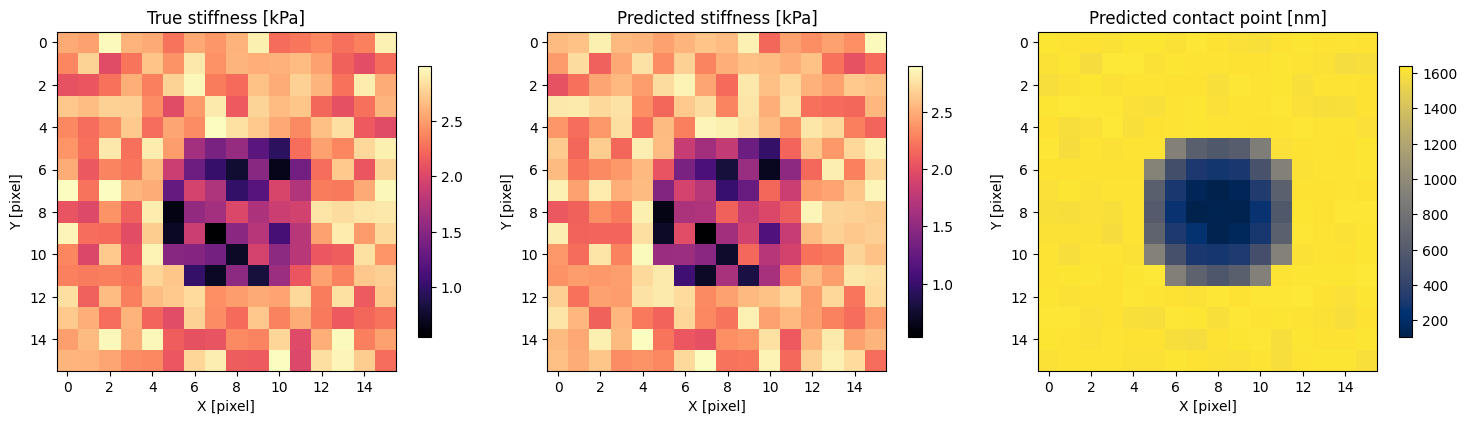

Test stiffness RMSE: 0.10 kPa
Test contact-point RMSE: 29.6 nm


In [ ]:
def predict_and_denormalise(
    model: nn.Module, 
    curve_inputs: np.ndarray, 
    target_stats: dict,
    batch_size: int = 256, device: torch.device = None,
    predict_contact_point: bool = True
    ) -> dict:
    """Run inference and de-normalise to physical units.

    Parameters
    ----------
    model : nn.Module
    curve_inputs : ndarray
    target_stats : dict
    batch_size : int, optional
    device : torch.device, optional
    predict_contact_point : bool, optional

    Returns
    -------
    dict
        ``stiffness_predictions_kpa`` and optionally ``cp_predictions_nm``.
    """
    # device = torch.device("cpu") if device is None else device
    model.eval()
    norm_e_list, norm_cp_list = [], []

    with torch.no_grad():
        for start in range(0, curve_inputs.shape[0], batch_size):
            pred = model(
                torch.tensor(curve_inputs[start:start + batch_size],
                             dtype=torch.float32, device=device)
            ).cpu().numpy()
            norm_e_list.append(pred[:, 0])
            if predict_contact_point:
                norm_cp_list.append(pred[:, 1])

    out = {"stiffness_predictions_kpa": denormalise_stiffness(
        np.concatenate(norm_e_list), target_stats
    )}
    if predict_contact_point:
        out["cp_predictions_nm"] = denormalise_contact_point(
            np.concatenate(norm_cp_list), target_stats
        )
    return out


prediction_output = predict_and_denormalise(
    model=trained_model,
    curve_inputs=test_flat["curve_inputs"],
    target_stats=target_stats,
    batch_size=model_config.batch_size,
    device="cpu",
    predict_contact_point=model_config.predict_contact_point,
)

predicted_stiffness_maps_kpa = prediction_output["stiffness_predictions_kpa"].reshape(
    test_collection["stiffness_maps_kpa"].shape
)
predicted_contact_point_maps_nm = None
if model_config.predict_contact_point:
    predicted_contact_point_maps_nm = prediction_output["cp_predictions_nm"].reshape(
        test_collection["contact_point_maps_nm"].shape
    )

sample_to_display = model_config.default_sample_to_display
n_panels = 3 if model_config.predict_contact_point else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
axes = np.atleast_1d(axes)

im_true = axes[0].imshow(test_collection["stiffness_maps_kpa"][sample_to_display], cmap="magma")
axes[0].set_title("True stiffness [kPa]")
axes[0].set_xlabel("X [pixel]"); axes[0].set_ylabel("Y [pixel]")
plt.colorbar(im_true, ax=axes[0], shrink=0.8)

im_pred = axes[1].imshow(predicted_stiffness_maps_kpa[sample_to_display], cmap="magma")
axes[1].set_title("Predicted stiffness [kPa]")
axes[1].set_xlabel("X [pixel]"); axes[1].set_ylabel("Y [pixel]")
plt.colorbar(im_pred, ax=axes[1], shrink=0.8)

if model_config.predict_contact_point:
    im_cp = axes[2].imshow(predicted_contact_point_maps_nm[sample_to_display], cmap="cividis")
    axes[2].set_title("Predicted contact point [nm]")
    axes[2].set_xlabel("X [pixel]"); axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(im_cp, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig('output.png')
plt.show()


stiffness_rmse = np.sqrt(np.mean(
    (predicted_stiffness_maps_kpa - test_collection["stiffness_maps_kpa"]) ** 2
))
print(f"Test stiffness RMSE: {stiffness_rmse:.2f} kPa")

if model_config.predict_contact_point:
    cp_rmse = np.sqrt(np.mean(
        (predicted_contact_point_maps_nm - test_collection["contact_point_maps_nm"]) ** 2
    ))
    print(f"Test contact-point RMSE: {cp_rmse:.1f} nm")


In [ ]:
from pathlib import Path

save_dir = Path("models")
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "afm_curve_cnn.pt"
checkpoint = {
    "model_state_dict": trained_model.state_dict(),
    "target_stats": target_stats,
    "normalization_stats": {
        **normalization_stats,
        "max_curve_length": int(max_curve_length),
        "z_length_nm": float(simulation_config.z_length_m * 1e9),
    },
    "model_config": {
        "in_channels": int(train_flat["curve_inputs"].shape[1]),
        "hidden_channels": (16, 32, 64),
        "predict_contact_point": model_config.predict_contact_point,
        "max_curve_length": int(max_curve_length),
    },
}

torch.save(checkpoint, save_path)
print(f"Saved model to: {save_path}")


Saved model to: models/afm_curve_cnn.pt


## 15. Clickable stiffness-map viewer


Interactive Plotly viewer is unavailable in this environment.
Install these packages locally and restart the kernel:
pip install plotly anywidget ipywidgets
Import error: No module named 'anywidget'
Interactive viewer not available. Using static fallback.


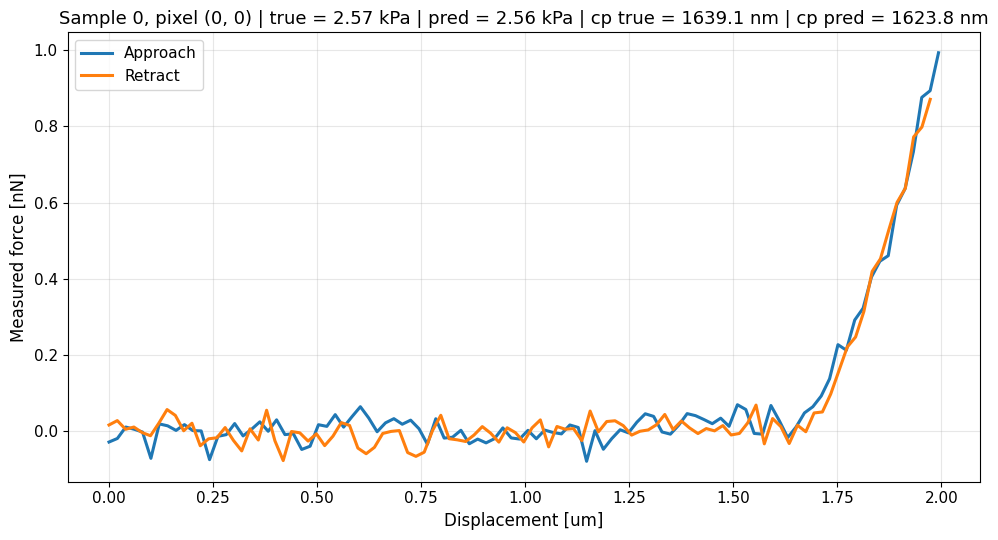

In [ ]:
from pathlib import Path
from IPython.display import display
import matplotlib
import matplotlib.animation 

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    output = None

try:
    import anywidget
    import ipywidgets as widgets
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("Plotly FigureWidget is available.")
except Exception as error:
    widgets = None
    go = None
    PLOTLY_AVAILABLE = False
    print("Interactive Plotly viewer is unavailable in this environment.")
    print("Install these packages locally and restart the kernel:")
    print("pip install plotly anywidget ipywidgets")
    print(f"Import error: {error}")


def show_curve_for_pixel(
    sample_index: int, 
    row_index: int, 
    col_index: int
    ) -> None:
    """Static fallback: plot the force curve for one pixel."""
    displacement_curve_um = test_collection["displacement_curves_um"][sample_index, row_index, col_index]
    curve_nN = test_collection["measured_force_curves_nN"][sample_index, row_index, col_index]
    valid_length = int(test_collection["curve_lengths"][sample_index, row_index, col_index])
    retract_start = int(test_collection["retract_start_indices"][sample_index, row_index, col_index])
    true_kpa = test_collection["stiffness_maps_kpa"][sample_index, row_index, col_index]
    pred_kpa = predicted_stiffness_maps_kpa[sample_index, row_index, col_index]
    title = (
        f"Sample {sample_index}, pixel ({row_index}, {col_index}) | "
        f"true = {true_kpa:.2f} kPa | pred = {pred_kpa:.2f} kPa"
    )
    if model_config.predict_contact_point and predicted_contact_point_maps_nm is not None:
        cp_true = test_collection["contact_point_maps_nm"][sample_index, row_index, col_index]
        cp_pred = predicted_contact_point_maps_nm[sample_index, row_index, col_index]
        title += f" | cp true = {cp_true:.1f} nm | cp pred = {cp_pred:.1f} nm"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.plot(displacement_curve_um[:retract_start], curve_nN[:retract_start], label="Approach", linewidth=2.2)
    ax.plot(
        displacement_curve_um[retract_start:valid_length],
        curve_nN[retract_start:valid_length],
        label="Retract",
        linewidth=2.2,
    )
    ax.set_xlabel("Displacement [um]", fontsize=12)
    ax.set_ylabel("Measured force [nN]", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    plt.show()


def display_clickable_stiffness_map(
    sample_index: int = 0,
    map_width: int = 560,
    map_height: int = 560,
    curve_width: int = 980,
    curve_height: int = 560,
) -> None:
    """Display a clickable predicted stiffness map linked to a force-curve panel."""
    if not PLOTLY_AVAILABLE:
        print("Interactive viewer not available. Using static fallback.")
        show_curve_for_pixel(sample_index, 0, 0)
        return

    pred_map = predicted_stiffness_maps_kpa[sample_index]
    true_map = test_collection["stiffness_maps_kpa"][sample_index]
    curves_nN = test_collection["measured_force_curves_nN"][sample_index]
    disp_um = test_collection["displacement_curves_um"][sample_index]
    curve_lengths = test_collection["curve_lengths"][sample_index]
    retract_starts = test_collection["retract_start_indices"][sample_index]
    cp_true_map = (
        test_collection["contact_point_maps_nm"][sample_index]
        if model_config.predict_contact_point else None
    )
    cp_pred_map = (
        predicted_contact_point_maps_nm[sample_index]
        if model_config.predict_contact_point and predicted_contact_point_maps_nm is not None
        else None
    )

    heatmap_fig = go.FigureWidget(data=[go.Heatmap(
        z=pred_map,
        colorscale="magma",
        colorbar={"title": "kPa", "thickness": 18},
        hovertemplate="x=%{x}<br>y=%{y}<br>pred=%{z:.2f} kPa<extra></extra>",
    )])
    heatmap_fig.update_layout(
        title={"text": f"Predicted Stiffness Sample {sample_index}", "y": 0.98, "x": 0.5, "xanchor": "center", "yanchor": "top", "font": {"size": 20}},
        xaxis_title="X",
        yaxis_title="Y",
        width=map_width,
        height=map_height,
        margin=dict(l=55, r=20, t=55, b=55),
        font={"size": 14},
    )
    heatmap_fig.update_yaxes(autorange="reversed", tickfont={"size": 12}, title_font={"size": 15})
    heatmap_fig.update_xaxes(tickfont={"size": 12}, title_font={"size": 15})

    curve_fig = go.FigureWidget(data=[
        go.Scatter(name="Approach", mode="lines", line={"width": 3}),
        go.Scatter(name="Retract", mode="lines", line={"width": 3}),
    ])
    curve_fig.update_layout(
        title={"text": "Select a pixel", "y": 0.98, "x": 0.5, "xanchor": "center", "yanchor": "top", "font": {"size": 18}},
        xaxis_title="Displacement [um]",
        yaxis_title="Force [nN]",
        width=curve_width,
        height=curve_height,
        margin=dict(l=60, r=25, t=75, b=55),
        legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99, font={"size": 13}),
        font={"size": 14},
    )
    curve_fig.update_xaxes(tickfont={"size": 12}, title_font={"size": 15})
    curve_fig.update_yaxes(tickfont={"size": 12}, title_font={"size": 15})

    def handle_click(trace, points, selector):
        if not points.xs:
            return
        col_index = int(points.xs[0])
        row_index = int(points.ys[0])
        valid_length = int(curve_lengths[row_index, col_index])
        retract_start = int(retract_starts[row_index, col_index])
        x_curve = disp_um[row_index, col_index]
        y_curve = curves_nN[row_index, col_index]
        title = (
            f"Pixel ({row_index}, {col_index}) | "
            f"True {true_map[row_index, col_index]:.1f} kPa | "
            f"Predicted {pred_map[row_index, col_index]:.1f} kPa"
        )
        if cp_true_map is not None and cp_pred_map is not None:
            title += (
                f"<br>Contact point true {cp_true_map[row_index, col_index]:.0f} nm | "
                f"predicted {cp_pred_map[row_index, col_index]:.0f} nm"
            )
        with curve_fig.batch_update():
            curve_fig.data[0].x = x_curve[:retract_start]
            curve_fig.data[0].y = y_curve[:retract_start]
            curve_fig.data[1].x = x_curve[retract_start:valid_length]
            curve_fig.data[1].y = y_curve[retract_start:valid_length]
            if valid_length < x_curve.shape[0]:
                curve_fig.data[2].x = x_curve[valid_length - 1:]
                curve_fig.data[2].y = y_curve[valid_length - 1:]
            else:
                curve_fig.data[2].x = []
                curve_fig.data[2].y = []
            curve_fig.layout.title.text = title

    heatmap_fig.data[0].on_click(handle_click)
    display(
        widgets.HBox(
            [heatmap_fig, curve_fig],
            layout=widgets.Layout(width="100%", justify_content="space-between", align_items="center"),
        )
    )


display_clickable_stiffness_map(sample_index=model_config.default_sample_to_display)

In [ ]:
checkpoint = torch.load("models/afm_curve_cnn.pt", map_location="cpu")
loaded_model = AFMCurveCNN(
    in_channels=checkpoint["model_config"]["in_channels"],
    hidden_channels=tuple(checkpoint["model_config"]["hidden_channels"]),
    predict_contact_point=checkpoint["model_config"]["predict_contact_point"],
)
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

target_stats = checkpoint["target_stats"]
normalization_stats = checkpoint["normalization_stats"]

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
sys.path.append(os.path.abspath("../scripts"))
import analyze_experimental_curves as aec
aec = importlib.reload(aec)

def _to_training_approach_z(
    z_m: np.ndarray
    ) -> np.ndarray:
    """Map z to training convention: 0 at far-from-surface, max near contact."""
    z_m = np.asarray(z_m, dtype=np.float64)
    if z_m.size == 0:
        return z_m
    z_max = float(np.nanmax(z_m))
    if z_m.size > 1 and z_m[0] > z_m[-1]:
        z_m = z_max - z_m
    return z_m


def _build_double_approach_curve(
    z_app_m: np.ndarray, 
    f_app_n: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Create a two-phase curve by using the approach twice.

    First half: original approach.
    Second half: the same approach samples reversed in time so the stitched curve
    stays continuous at the phase boundary while avoiding any external retract file.
    """
    z_app_m = np.asarray(z_app_m, dtype=np.float64)
    f_app_n = np.asarray(f_app_n, dtype=np.float64)

    z_second = z_app_m[::-1].copy()
    f_second = f_app_n[::-1].copy()

    z_full = np.concatenate([z_app_m, z_second])
    f_full = np.concatenate([f_app_n, f_second])
    phase_full = np.concatenate([
        -np.ones(z_app_m.shape[0], dtype=np.float32),
        np.ones(z_second.shape[0], dtype=np.float32),
    ])
    return z_full, f_full, phase_full


# 1. EXTRACT APPROACH CURVES ONLY

approach_file_paths = [
    "../data/3t3_cell_dataset/approach/2527.npy",
    "../data/3t3_cell_dataset/approach/500.npy",
]

extracted_data = aec.extract_fdc_data(approach_file_paths)

n_curves = len(extracted_data["z_um"])
for i, path in enumerate(approach_file_paths):
    print(
        f"  Curve {i}: approach={os.path.basename(path)} | second half = duplicated approach"
    )

n_points_half = 1500
spring_k = 0.02  # N/m

z_phys_list = []
f_phys_list = []
phase_list = []
preprocess_info_list = []
retract_used_list = []

for i, (z_um, f_nN) in enumerate(zip(extracted_data["z_um"], extracted_data["force_nN"])):
    z_app_m_raw = z_um * 1e-6
    f_app_n_raw = f_nN * 1e-9

    _, _, z_app_m, f_app_n, info = aec.preprocess_curve(
        z_app_m_raw,
        f_app_n_raw,
        smooth=False,
        n_points=n_points_half,
        spring_k=spring_k,
        use_tip_position=True,
        tip_sign="auto",
        return_info=True,
    )

    z_app_m = _to_training_approach_z(z_app_m)
    z_phys_orig_max = float(np.nanmax(z_app_m))
    info["z_phys_orig_max_m"] = z_phys_orig_max

    z_full_m, f_full_n, phase_full = _build_double_approach_curve(z_app_m, f_app_n)

    z_phys_list.append(z_full_m)
    f_phys_list.append(f_full_n)
    phase_list.append(phase_full)
    preprocess_info_list.append(info)
    retract_used_list.append(False)

    print(
        f"  Curve {i}: points={z_full_m.size}, "
        f"z=[{z_full_m.min()*1e9:.1f}, {z_full_m.max()*1e9:.1f}] nm, "
        f"f=[{f_full_n.min()*1e9:.2f}, {f_full_n.max()*1e9:.2f}] nN, "
        f"second_half=approach_copy"
    )

# 3. PREPARE INPUTS FOR MODEL PREDICTION
# Match training input channel order:
# [force_norm, valid_mask, phase_channel, z_scaled_channel]

force_scale_nN = float(normalization_stats.get("force_scale_nN", 1.0))
z_scale_um = float(normalization_stats.get("z_scale_um", simulation_config.z_length_m * 1e6))

n_points_total = 2 * n_points_half
curve_inputs = np.zeros((n_curves, 4, n_points_total), dtype=np.float32)

for i in range(n_curves):
    z_curve_m = np.asarray(z_phys_list[i], dtype=np.float64)
    f_curve_n = np.asarray(f_phys_list[i], dtype=np.float64)
    phase_curve = np.asarray(phase_list[i], dtype=np.float32)

    raw_force_nN = (f_curve_n * 1e9).astype(np.float32)
    force_norm = raw_force_nN / (force_scale_nN + 1e-30)

    valid_mask = np.ones(n_points_total, dtype=np.float32)
    z_scaled_channel = ((z_curve_m * 1e6) / (z_scale_um + 1e-30)).astype(np.float32)

    curve_inputs[i, 0, :] = (force_norm * valid_mask).astype(np.float32)
    curve_inputs[i, 1, :] = valid_mask
    curve_inputs[i, 2, :] = phase_curve
    curve_inputs[i, 3, :] = z_scaled_channel

print(f"  Input shape for model: {curve_inputs.shape}")
print(f"  Model expects channels: {loaded_model.backbone[0].in_channels}")

# 4. PREDICT WITH MODEL

with torch.no_grad():
    curve_tensor = torch.tensor(curve_inputs, dtype=torch.float32, device="cpu")
    predictions = loaded_model(curve_tensor).cpu().numpy()

# Extract stiffness (always predicted) and contact point (if applicable)
pred_stiffness_norm = predictions[:, 0]
pred_stiffness_kpa = denormalise_stiffness(pred_stiffness_norm, target_stats)

if model_config.predict_contact_point and predictions.shape[1] > 1:
    pred_cp_norm = predictions[:, 1]
    pred_cp_nm = denormalise_contact_point(pred_cp_norm, target_stats)
else:
    pred_cp_nm = None

print(f"  Predicted stiffness: {pred_stiffness_kpa}")
if pred_cp_nm is not None:
    print(f"  Predicted contact points (in flipped z space, nm): {pred_cp_nm}")

# 5. COMPARE WITH REFERENCE DATA

comparison_results = []

for i in range(n_curves):
    result = {
        "filename": extracted_data["filenames"][i],
        "retract_used": retract_used_list[i],
        "pred_stiffness_kpa": pred_stiffness_kpa[i],
    }

    if extracted_data["E_pa"][i] is not None:
        result["ref_stiffness_kpa"] = extracted_data["E_pa"][i] / 1e3
        result["stiffness_error_kpa"] = abs(pred_stiffness_kpa[i] - result["ref_stiffness_kpa"])
        result["stiffness_error_percent"] = 100 * result["stiffness_error_kpa"] / result["ref_stiffness_kpa"]
    else:
        result["ref_stiffness_kpa"] = np.nan
        result["stiffness_error_kpa"] = np.nan
        result["stiffness_error_percent"] = np.nan

    if pred_cp_nm is not None:
        result["pred_cp_nm"] = pred_cp_nm[i]
        if extracted_data["cp_m"][i] is not None:
            cp_raw_m = float(extracted_data["cp_m"][i])
            z_offset_m = float(preprocess_info_list[i].get("z_offset_m", 0.0))
            z_phys_orig_max_m = float(preprocess_info_list[i].get("z_phys_orig_max_m", 0.0))
            cp_phys_orig = aec.adapt_cp_to_processed_z(cp_raw_m, z_offset_m)
            cp_ref_flipped_m = z_phys_orig_max_m - cp_phys_orig
            result["ref_cp_nm"] = cp_ref_flipped_m * 1e9
            result["cp_error_nm"] = abs(pred_cp_nm[i] - result["ref_cp_nm"])
        else:
            result["ref_cp_nm"] = np.nan
            result["cp_error_nm"] = np.nan

    comparison_results.append(result)

comparison_df = pd.DataFrame(comparison_results)

print("COMPARISON TABLE")
display(comparison_df)

has_ref = comparison_df["ref_stiffness_kpa"].notna()
if has_ref.any():
    rmse_kpa = np.sqrt(np.mean(comparison_df.loc[has_ref, "stiffness_error_kpa"]**2))
    mean_error_pct = comparison_df.loc[has_ref, "stiffness_error_percent"].mean()
    print("\nStiffness predictions (vs. reference):")
    print(f"  RMSE: {rmse_kpa:.2f} kPa")
    print(f"  Mean error: {mean_error_pct:.2f}%")

if pred_cp_nm is not None:
    has_ref_cp = comparison_df["ref_cp_nm"].notna()
    if has_ref_cp.any():
        rmse_nm = np.sqrt(np.mean(comparison_df.loc[has_ref_cp, "cp_error_nm"]**2))
        mean_error_nm = comparison_df.loc[has_ref_cp, "cp_error_nm"].mean()
        print("\nContact point predictions (vs. reference, in flipped z space):")
        print(f"  RMSE: {rmse_nm:.2f} nm")
        print(f"  Mean error: {mean_error_nm:.2f} nm")

STEP 1: EXTRACT FDC DATA FROM .NPY FILES
  ✓ Loaded: 2527.npy (3000 points)
  ✓ Loaded: 500.npy (3000 points)

Successfully extracted 2 curves
  Curve 0: approach=2527.npy | second half = duplicated approach
  Curve 1: approach=500.npy | second half = duplicated approach
STEP 2: PREPROCESS AND DOUBLE THE APPROACH CURVE
  Curve 0: points=3000, z=[0.0, 3093.4] nm, f=[-0.03, 0.75] nN, second_half=approach_copy
  Curve 1: points=3000, z=[0.0, 2848.7] nm, f=[-0.03, 0.77] nN, second_half=approach_copy
STEP 3: PREPARE MODEL INPUTS
  Input shape for model: (2, 4, 3000)
  Model expects channels: 4
STEP 4: MODEL PREDICTIONS
  Predicted stiffness: [2.6492052 2.309617 ]
  Predicted contact points (in flipped z space, nm): [1764.9578 1711.415 ]
STEP 5: COMPARISON WITH REFERENCE DATA
COMPARISON TABLE


,filename,retract_used,pred_stiffness_kpa,ref_stiffness_kpa,stiffness_error_kpa,stiffness_error_percent,pred_cp_nm,ref_cp_nm,cp_error_nm
0,../data/3t3_cell_dataset/approach/2527.npy,False,2.649205,1.45538,1.193825,82.028419,1764.957764,2650.741894,885.784180
1,../data/3t3_cell_dataset/approach/500.npy,False,2.309617,1.13369,1.175927,103.725624,1711.415039,2335.961949,624.546875



Stiffness predictions (vs. reference):
  RMSE: 1.18 kPa
  Mean error: 92.88%

Contact point predictions (vs. reference, in flipped z space):
  RMSE: 766.38 nm
  Mean error: 755.17 nm


STEP 7: HERTZ OVERLAY (MODEL-PREDICTED VS FILE-REFERENCE)
Saved overlay figure to: results/hertz_overlay_model_vs_file.png


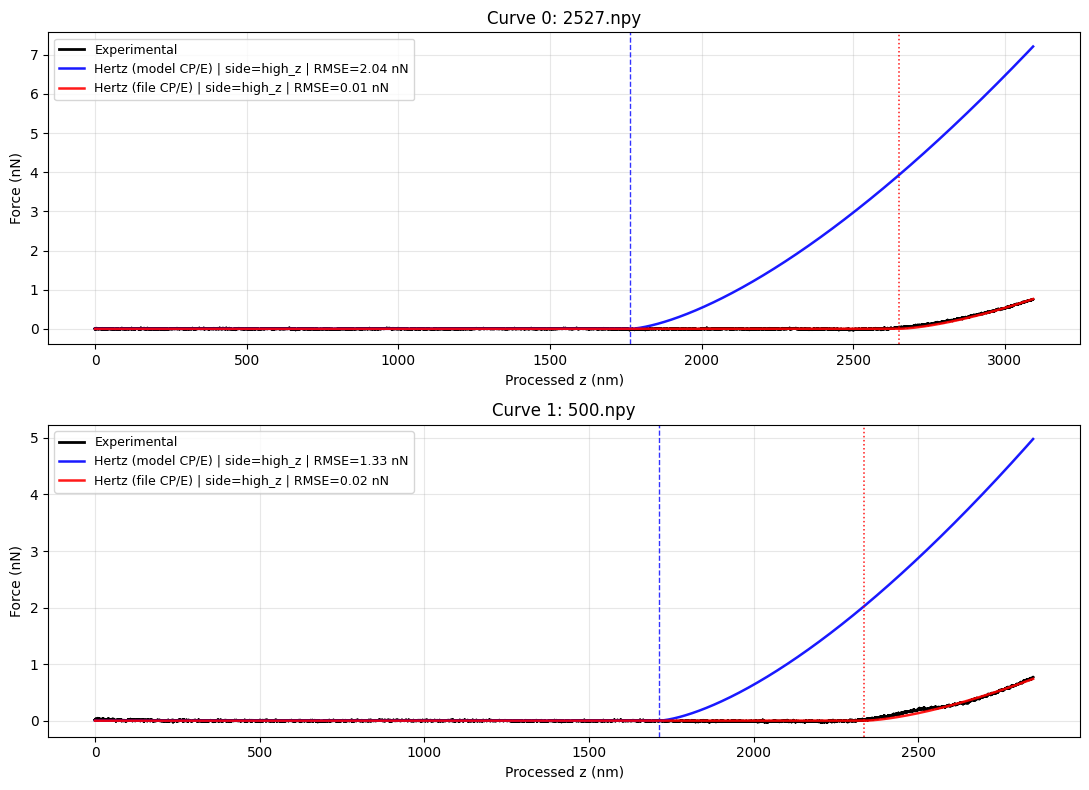

In [ ]:
# 6. CONTACT-MECHANICS OVERLAY: MODEL VS FILE REFERENCE
# Use current contact-model geometry if available, otherwise fall back to a
# typical AFM value used above.

if "contact_model" in globals() and hasattr(contact_model, "R"):
    tip_radius_m = float(contact_model.R)
else:
    tip_radius_m = 1000e-9

# Use Poisson ratio from contact model when available.
if "contact_model" in globals() and hasattr(contact_model, "nu"):
    nu = float(contact_model.nu)
else:
    nu = 0.5

hertz_prefactor = (4.0 / 3.0) * np.sqrt(tip_radius_m) / (1.0 - nu**2)

def hertz_force_from_cp_and_e(
    z_m: np.ndarray, 
    cp_m: float, 
    e_pa: float, 
    force_exp_n: np.ndarray
    ) -> tuple[np.ndarray, str, float]:
    """Compute Hertz force from (cp, E) and choose best contact side.

    Two indentation directions are tested:
    - high-z contact: delta = max(z - cp, 0)
    - low-z contact : delta = max(cp - z, 0)

    The direction with lower RMSE to experimental force is selected.
    """
    z_m = np.asarray(z_m, dtype=np.float64)
    force_exp_n = np.asarray(force_exp_n, dtype=np.float64)

    delta_high = np.clip(z_m - cp_m, 0.0, None)
    force_high = hertz_prefactor * float(e_pa) * np.power(delta_high, 1.5)
    rmse_high = float(np.sqrt(np.mean((force_high - force_exp_n) ** 2)))

    delta_low = np.clip(cp_m - z_m, 0.0, None)
    force_low = hertz_prefactor * float(e_pa) * np.power(delta_low, 1.5)
    rmse_low = float(np.sqrt(np.mean((force_low - force_exp_n) ** 2)))

    if rmse_high <= rmse_low:
        return force_high, "high_z", rmse_high
    return force_low, "low_z", rmse_low


if "comparison_df" not in globals() or comparison_df.empty:
    print("No comparison table found. Run the previous prediction cell first.")
else:
    n_show = len(comparison_df)
    fig, axes = plt.subplots(n_show, 1, figsize=(11, max(4.5, 4.0 * n_show)), squeeze=False)

    for i in range(n_show):
        ax = axes[i, 0]

        z_m_full = np.asarray(z_phys_list[i], dtype=np.float64)
        f_exp_n_full = np.asarray(f_phys_list[i], dtype=np.float64)
        z_nm_full = z_m_full * 1e9

        # Plot full patched curve (approach + retract) for context.
        ax.plot(z_nm_full, f_exp_n_full * 1e9, color="black", lw=2.0, label="Experimental")

        # Use approach segment for Hertz evaluation when phase labels are available.
        if "phase_list" in globals() and i < len(phase_list):
            phase_curve = np.asarray(phase_list[i], dtype=np.float64)
        else:
            phase_curve = None

        if phase_curve is not None and phase_curve.shape == z_m_full.shape and np.any(phase_curve < 0):
            approach_mask = phase_curve < 0
            z_m = z_m_full[approach_mask]
            f_exp_n = f_exp_n_full[approach_mask]
        else:
            z_m = z_m_full
            f_exp_n = f_exp_n_full

        z_nm = z_m * 1e9

        # Model-predicted parameters
        cp_pred_m = np.nan
        e_pred_pa = np.nan
        if "pred_cp_nm" in comparison_df.columns and pd.notna(comparison_df.loc[i, "pred_cp_nm"]):
            cp_pred_m = float(comparison_df.loc[i, "pred_cp_nm"]) * 1e-9
        if "pred_stiffness_kpa" in comparison_df.columns and pd.notna(comparison_df.loc[i, "pred_stiffness_kpa"]):
            e_pred_pa = float(comparison_df.loc[i, "pred_stiffness_kpa"]) * 1e3

        if np.isfinite(cp_pred_m) and np.isfinite(e_pred_pa) and e_pred_pa > 0:
            f_pred_n, side_pred, rmse_pred_n = hertz_force_from_cp_and_e(
                z_m=z_m,
                cp_m=cp_pred_m,
                e_pa=e_pred_pa,
                force_exp_n=f_exp_n,
            )
            ax.plot(
                z_nm,
                f_pred_n * 1e9,
                color="blue",
                lw=1.8,
                alpha=0.9,
                label=(
                    f"Hertz (model CP/E) | side={side_pred} | "
                    f"RMSE={rmse_pred_n*1e9:.2f} nN"
                ),
            )
            ax.axvline(cp_pred_m * 1e9, color="blue", ls="--", lw=1.0, alpha=0.8)

        # File-reference parameters (CP from file adapted to processed z, E from file)
        cp_ref_m = np.nan
        e_ref_pa = np.nan
        if extracted_data["cp_m"][i] is not None:
            cp_raw_m = float(extracted_data["cp_m"][i])
            z_offset_m = float(preprocess_info_list[i].get("z_offset_m", 0.0))
            z_phys_orig_max_m = float(preprocess_info_list[i].get("z_phys_orig_max_m", 0.0))
            # Convert file CP from decreasing z_phys space to flipped (training) z space
            cp_phys_orig = aec.adapt_cp_to_processed_z(cp_raw_m, z_offset_m)
            cp_ref_m = z_phys_orig_max_m - cp_phys_orig
        if extracted_data["E_pa"][i] is not None:
            e_ref_pa = float(extracted_data["E_pa"][i])

        if np.isfinite(cp_ref_m) and np.isfinite(e_ref_pa) and e_ref_pa > 0:
            f_ref_n, side_ref, rmse_ref_n = hertz_force_from_cp_and_e(
                z_m=z_m,
                cp_m=cp_ref_m,
                e_pa=e_ref_pa,
                force_exp_n=f_exp_n,
            )
            ax.plot(
                z_nm,
                f_ref_n * 1e9,
                color="red",
                lw=1.8,
                alpha=0.9,
                label=(
                    f"Hertz (file CP/E) | side={side_ref} | "
                    f"RMSE={rmse_ref_n*1e9:.2f} nN"
                ),
            )
            ax.axvline(cp_ref_m * 1e9, color="red", ls=":", lw=1.1, alpha=0.9)

        file_label = comparison_df.loc[i, "filename"] if "filename" in comparison_df.columns else f"Curve {i}"
        ax.set_title(f"Curve {i}: {os.path.basename(str(file_label))}")
        ax.set_xlabel("Processed z (nm)")
        ax.set_ylabel("Force (nN)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc="best")

    plt.tight_layout()
    os.makedirs("results", exist_ok=True)
    overlay_path = "results/hertz_overlay_model_vs_file.png"
    plt.savefig(overlay_path, dpi=160, bbox_inches="tight")
    print(f"Saved overlay figure to: {overlay_path}")
    plt.show()